In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load your downloaded dataset
# Loads the dataset into a DataFrame (an "Excel-like" table object).
df = pd.read_csv('Housing.csv')

# 2. Select Target
# Extracts the 'price' column. .values converts it from a Pandas Series to a NumPy array.
y = df['price'].values
print("Target variable 'price' loaded! and its shape is : ", y.shape)

# 3. Select Features for Model 1 (Single) and Model 2 (Multiple here 6)
feature_m1 = ['area']
features_m2 = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad']
print("Selected features for Model 1: ", feature_m1)
print("Selected features for Model 2: ", features_m2)

# Convert categorical 'yes/no' to 1/0 if necessary (e.g., for 'mainroad')
# Computers can't do math on the string "yes." .map() replaces "yes" with 1 and "no" with 0.
if 'mainroad' in df.columns:
    df['mainroad'] = df['mainroad'].map({'yes': 1, 'no': 0})

# 4. Standardization Function (Mandatory for Gradient Descent)
#  This performs Z-score normalization. It makes the mean of each feature $0$ and the standard deviation $1$.
# Why it's Mandatory: Without this, Gradient Descent fails. If 'area' is $5000$ and 'bedrooms' is $3$, the gradient for area will be massive,
#  and the model will "overshoot" or diverge. 
# Standardization makes the loss function look like a round bowl rather than a thin, stretched-out oval.
def standardize(X):
    return (X - np.mean(X, axis=0)) / np.std(X, axis=0)

# Prepare X1 (Model 1) and X2 (Model 2)
X1 = standardize(df[feature_m1].values) # Shape (n, 1)
X2 = standardize(df[features_m2].values) # Shape (n, 6)

print("Data Prepared!")
print(f"Model 1 shape: {X1.shape}")
print(f"Model 2 shape: {X2.shape}")

Target variable 'price' loaded! and its shape is :  (545,)
Selected features for Model 1:  ['area']
Selected features for Model 2:  ['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad']
Data Prepared!
Model 1 shape: (545, 1)
Model 2 shape: (545, 6)


In [14]:
class LinearRegressionScratch:
    def __init__ (self,eta=0.01,epochs=1000):
        self.eta=eta
        self.epochs=epochs
        self.train_loss=[]
        self.theta=None
        self.theta_history=[]
    
    def compute_loss(self,X,y):
        # X shape: (m+1, n)
        # y shape: (n, 1)
        # self.theta shape: (m+1, 1)
    
        n = X.shape[1]
        h = np.dot(X.T, self.theta) # (n, 1)
        term = h - y.reshape(n, 1)   # (n, 1)
    
        # Loss = 1/n * (term_transpose @ term)
        loss = (1 / n) * np.dot(term.T, term)
    
        return loss.item() # Returns a single number for easy plotting
       

    # X here means X_train, and y means y_train
    def fit(self,X,y):
        # Transpose X to (m, n)
        X = X.T 
        m, n = X.shape
        
        # Add bias row -> X is now (m+1, n)
        X = np.vstack((np.ones((1, n)), X))

        # Ensure y is (n, 1)
        y = y.reshape(n, 1)
        
        # Initialize θ = (m+1, 1)
        self.theta = np.zeros((m + 1, 1))

        for _ in range(self.epochs):
            # h = (n, 1)
            h = np.dot(X.T, self.theta)

            # Gradient = (m+1, 1)
            gradient = (2/ n) * np.dot(X, (h - y))

            # Update
            self.theta -= self.eta * gradient

            # Track
            self.train_loss.append(self.compute_loss(X, y))
            self.theta_history.append(self.theta.copy())

    
    def predict(self,X):
        n,m= X.shape
        # X is now m*n
        X=X.T
        
        # X is now (m+1)*n
        X = np.vstack((np.ones((1, X.shape[1])), X))

        return np.dot(X.T,self.theta).flatten()
        

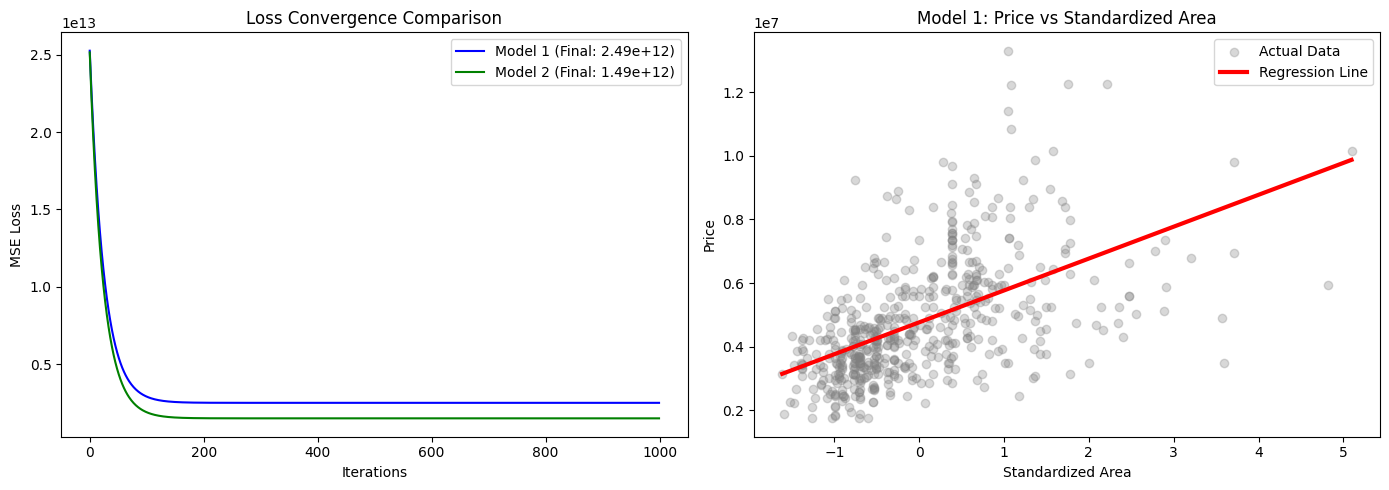

Model 1 Final Loss: 2488861398180.6577
Model 2 Final Loss: 1485356545740.4509
Conclusion: Model 2 is better by 40.32%. More features helped reduce the error.


In [15]:
# --- 1. INITIALIZE AND TRAIN ---
# Training both models with the same parameters for a fair comparison
model1 = LinearRegressionScratch(eta=0.01, epochs=1000)
model2 = LinearRegressionScratch(eta=0.01, epochs=1000)

model1.fit(X1, y) 
model2.fit(X2, y)

# --- 2. PLOT LOSS AND REGRESSION LINE ---
# The Mean Squared Error (MSE) on the y-axis against 
# the number of iterations on the x-axis for both Model 1 and Model 2.
# Model 2 (green) should end at a lower point than Model 1 (blue). 
# This visually proves that adding more features (bathrooms, bedrooms, etc.) makes the prediction more accurate.
plt.figure(figsize=(14, 5))

# Subplot 1: Loss Convergence (For both models)
plt.subplot(1, 2, 1)
plt.plot(model1.train_loss, label=f'Model 1 (Final: {model1.train_loss[-1]:.2e})', color='blue')
plt.plot(model2.train_loss, label=f'Model 2 (Final: {model2.train_loss[-1]:.2e})', color='green')
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("Loss Convergence Comparison")
plt.legend()

# Subplot 2: Model 1 Regression Line (Single Feature)
# What it plots: A scatter plot of the actual house prices vs. area,
#  with your model's predicted "line of best fit" drawn over them.
plt.subplot(1, 2, 2)
# Flatten for plotting
x_vals = X1.flatten()
y_vals = y.flatten()

# Scatter plot of actual data
plt.scatter(x_vals, y_vals, color='gray', alpha=0.3, label='Actual Data')

# Predict and plot the regression line
preds = model1.predict(X1)
sort_idx = np.argsort(x_vals)
plt.plot(x_vals[sort_idx], preds[sort_idx], color='red', lw=3, label='Regression Line')

plt.title("Model 1: Price vs Standardized Area")
plt.xlabel("Standardized Area")
plt.ylabel("Price")
plt.legend()

plt.tight_layout()
plt.show()

# --- 3. PERFORMANCE COMPARISON ---
print(f"Model 1 Final Loss: {model1.train_loss[-1]:.4f}")
print(f"Model 2 Final Loss: {model2.train_loss[-1]:.4f}")



if model2.train_loss[-1] < model1.train_loss[-1]:
    improvement = ((model1.train_loss[-1] - model2.train_loss[-1]) / model1.train_loss[-1]) * 100
    print(f"Conclusion: Model 2 is better by {improvement:.2f}%. More features helped reduce the error.")



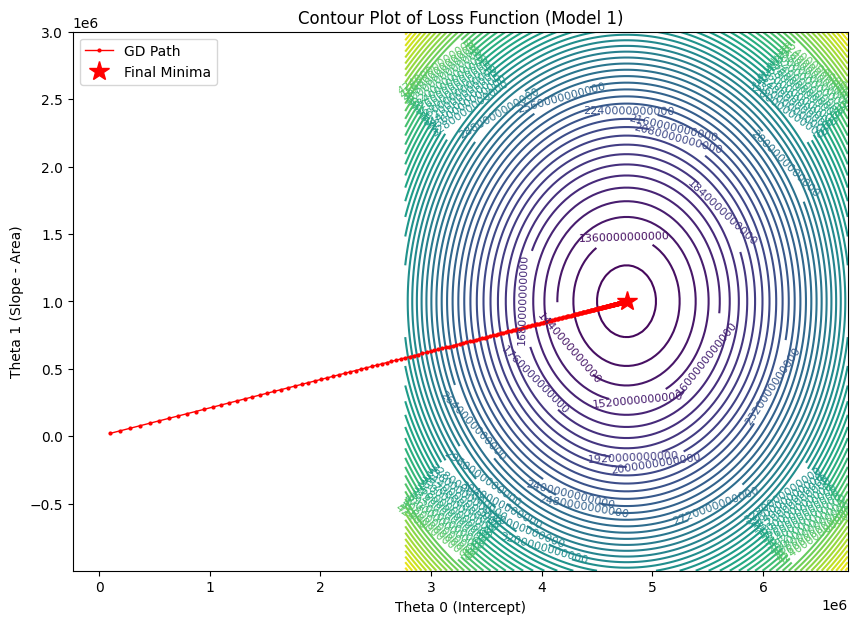

In [16]:
# --- CONTOUR PLOT FOR MODEL 1 ---
# 1. Access the final learned parameters from our class instance
# model1.theta is shape (2,1). [0,0] is intercept, [1,0] is slope.
theta0_final = model1.theta[0, 0]
theta1_final = model1.theta[1, 0]

# Create a grid of theta values around our final results
# We use a range of +/- 2 million because house prices are large numbers
t0_vals = np.linspace(theta0_final - 2e6, theta0_final + 2e6, 100)
t1_vals = np.linspace(theta1_final - 2e6, theta1_final + 2e6, 100)
T0, T1 = np.meshgrid(t0_vals, t1_vals)

# 2. Calculate the Cost (Loss) for every combination on the grid
Z = np.zeros(T0.shape)
# We use X1.flatten() because X1 is (n, 1) and we need a simple array for the math
x_features = X1.flatten() 

for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        # h = theta0 + theta1 * x
        predictions = T0[i, j] + T1[i, j] * x_features
        # Mean Squared Error: (1/2n) * sum(error^2)
        Z[i, j] = np.mean((predictions - y)**2) / 2

# 3. Plot the Contours
plt.figure(figsize=(10, 7))
cp = plt.contour(T0, T1, Z, levels=50, cmap='viridis')
plt.clabel(cp, inline=1, fontsize=8)

# 4. Plot the path followed by Gradient Descent
# Convert the list of theta arrays into a single 2D numpy array for plotting
# Each element in theta_history is (2, 1), so we flatten them to (2,)
history_path = np.array([t.flatten() for t in model1.theta_history])

# Path: Column 0 is theta0 history, Column 1 is theta1 history
plt.plot(history_path[:, 0], history_path[:, 1], 'ro-', markersize=2, linewidth=1, label='GD Path')
plt.plot(theta0_final, theta1_final, 'r*', markersize=15, label='Final Minima')

plt.title("Contour Plot of Loss Function (Model 1)")
plt.xlabel("Theta 0 (Intercept)")
plt.ylabel("Theta 1 (Slope - Area)")
plt.legend()
plt.show()

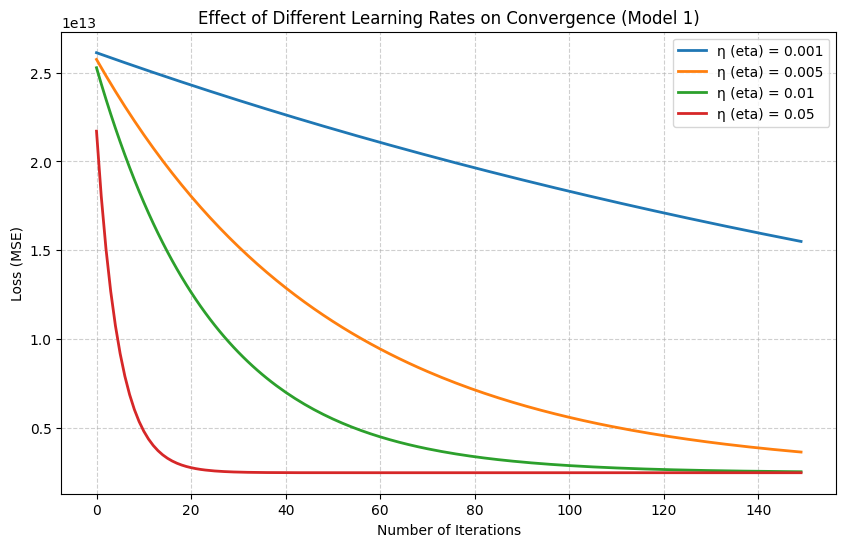


--- FINAL ANALYSIS ---
1. η = 0.05: Converges the fastest. The line drops sharply, showing the model takes large steps.
2. η = 0.001: Converges the slowest. The line is much flatter, meaning the steps are tiny.
3. Conclusion: A higher learning rate speeds up training, but setting it too high 
   could cause the gradient descent to overshoot the minimum and diverge.


In [17]:
# --- TASK: EFFECT OF DIFFERENT LEARNING RATES ---
# Define the learning rates to test
learning_rates = [0.001, 0.005, 0.01, 0.05]
num_iterations = 150  # We use fewer iterations to see the "speed" of the drop clearly

plt.figure(figsize=(10, 6))

for eta in learning_rates:
    # 1. Initialize the class with the specific learning rate
    model_lr = LinearRegressionScratch(eta=eta, epochs=num_iterations)
    
    # 2. Train the model (using Model 1's feature: Area)
    model_lr.fit(X1, y)
    
    # 3. Plot the loss history stored in the class instance
    plt.plot(model_lr.train_loss, label=f'η (eta) = {eta}', linewidth=2)

plt.title("Effect of Different Learning Rates on Convergence (Model 1)")
plt.xlabel("Number of Iterations")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- FINAL ANALYSIS COMMENTS ---
print("\n--- FINAL ANALYSIS ---")
print(f"1. η = 0.05: Converges the fastest. The line drops sharply, showing the model takes large steps.")
print(f"2. η = 0.001: Converges the slowest. The line is much flatter, meaning the steps are tiny.")
print("3. Conclusion: A higher learning rate speeds up training, but setting it too high ")
print("   could cause the gradient descent to overshoot the minimum and diverge.")

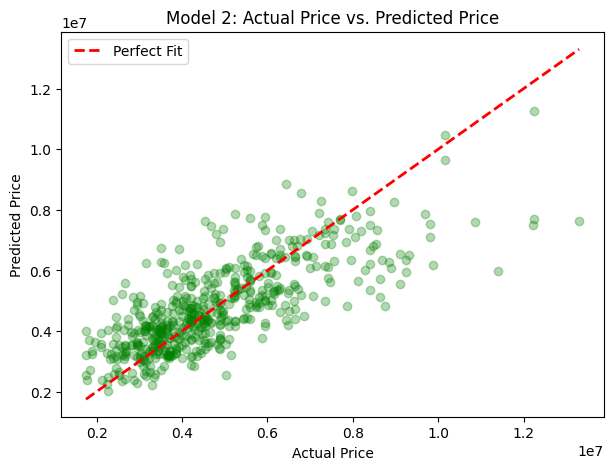


--- PERFORMANCE COMPARISON ---
Model 1 (Area only) Final Loss: 2488861398180.66
Model 2 (6 Features) Final Loss: 1485356545740.45
Improvement: Model 2 reduced loss by 40.32% compared to Model 1.


In [18]:
# --- ADD THIS TO SATISFY "PLOT FOR BOTH MODELS" ---
plt.figure(figsize=(7, 5))
preds2 = model2.predict(X2)

plt.scatter(y, preds2, color='green', alpha=0.3)
# Draw the "Perfect Fit" line
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Fit')

plt.title("Model 2: Actual Price vs. Predicted Price")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.show()

# --- ADD THIS TO SATISFY "COMPARE PERFORMANCE" ---
print("\n--- PERFORMANCE COMPARISON ---")
print(f"Model 1 (Area only) Final Loss: {model1.train_loss[-1]:.2f}")
print(f"Model 2 (6 Features) Final Loss: {model2.train_loss[-1]:.2f}")
improvement = ((model1.train_loss[-1] - model2.train_loss[-1]) / model1.train_loss[-1]) * 100
print(f"Improvement: Model 2 reduced loss by {improvement:.2f}% compared to Model 1.")